In [ ]:
import os
import random
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.20.0
GPU: []


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/MedicalExpert-II/MedicalExpert-II"
print("Dataset exists:", os.path.exists(DATA_DIR))


Mounted at /content/drive
Dataset exists: True


## 1. Build the dataframe — WITH dedup, before any split

This is the single source of truth. Nothing downstream rebuilds `df` from scratch, so the dedup can't get silently dropped like it did before.

In [ ]:
class_names = ["0Normal", "1Doubtful", "2Mild", "3Moderate", "4Severe"]

records = []
seen_hashes = set()
dupe_count = 0

for grade, class_name in enumerate(class_names):
    class_dir = os.path.join(DATA_DIR, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]

    for fname in files:
        path = os.path.join(class_dir, fname)
        with open(path, "rb") as fh:
            file_hash = hashlib.md5(fh.read()).hexdigest()

        if file_hash in seen_hashes:
            dupe_count += 1
            continue
        seen_hashes.add(file_hash)

        records.append({"filepath": path, "grade": grade})

df = pd.DataFrame(records)
print(f"Unique images kept: {len(df)}  (dropped {dupe_count} exact duplicates)")
print(df["grade"].value_counts().sort_index())


Unique images kept: 1633  (dropped 17 exact duplicates)
grade
0    502
1    485
2    227
3    213
4    206
Name: count, dtype: int64


## 2. Stratified split — locked, touch test only once at the end

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["grade"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["grade"], random_state=SEED
)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name} distribution:")
    print(split["grade"].value_counts().sort_index())


Train: 1143  Val: 245  Test: 245

Train distribution:
grade
0    351
1    340
2    159
3    149
4    144
Name: count, dtype: int64

Val distribution:
grade
0    75
1    73
2    34
3    32
4    31
Name: count, dtype: int64

Test distribution:
grade
0    76
1    72
2    34
3    32
4    31
Name: count, dtype: int64


## 3. ONE preprocessing function, used for train, val, AND test

Aspect-ratio-preserving pad (these images are ~2:1 to ~4:1 strips — a plain resize distorts the joint-space gap, which is the actual signal). No manual /255 — EfficientNetB0 has its own rescaling built in.

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image = tf.cast(image, tf.float32)
    image = tf.image.resize_with_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    image = tf.image.grayscale_to_rgb(image)
    return image, label

def make_dataset(split_df, training):
    ds = tf.data.Dataset.from_tensor_slices(
        (split_df["filepath"].values, split_df["grade"].values)
    )
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(len(split_df), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df,   training=False)
test_ds  = make_dataset(test_df,  training=False)   # do not evaluate this until the very last cell

print("Pipelines ready — identical preprocessing across all three splits.")


Pipelines ready — identical preprocessing across all three splits.


## 4. Augmentation (train only) + class weights (computed, not hand-tuned)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02, fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomTranslation(0.05, 0.05, fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomZoom((-0.05, 0.05), fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomContrast(0.10),
], name="medical_image_augmentation")

classes = np.array([0, 1, 2, 3, 4])
class_weights_array = compute_class_weight(
    class_weight="balanced", classes=classes, y=train_df["grade"]
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_array)}
print("Class weights (sklearn 'balanced', not hand-tuned):", class_weights)


Class weights (sklearn 'balanced', not hand-tuned): {0: 0.6512820512820513, 1: 0.6723529411764706, 2: 1.4377358490566037, 3: 1.534228187919463, 4: 1.5875}


## 5. Stage 1 — frozen EfficientNetB0 backbone, train the head

In [ ]:
def build_model():
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=(224, 224, 3)
    )
    base.trainable = False
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.20)(x)
    outputs = tf.keras.layers.Dense(5, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)
    return model, base

model, backbone = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ medical_image_augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
stage1_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_stage1.keras", monitor="val_loss", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True, verbose=1
    ),
]

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=stage1_callbacks,
)


Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2979 - loss: 1.5611
Epoch 1: val_loss improved from None to 1.19206, saving model to /content/best_stage1.keras

Epoch 1: finished saving model to /content/best_stage1.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.3500 - loss: 1.4792 - val_accuracy: 0.5184 - val_loss: 1.1921 - learning_rate: 0.0010
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4637 - loss: 1.3202
Epoch 2: val_loss improved from 1.19206 to 1.00370, saving model to /content/best_stage1.keras

Epoch 2: finished saving model to /content/best_stage1.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.4716 - loss: 1.2723 - val_accuracy: 0.5918 - val_loss: 1.0037 - learning_rate: 0.0010
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5191 - loss: 1.1569
Epoch 3: val_loss improved from 1.00370 to 0.98352, saving model to /content/best_stage1.keras

Epoch 3: finished saving model to /content/best_stage1.keras
36/3

## 6. Stage 2 — unfreeze top layers, fine-tune at low LR

Only checking val here. Test set stays untouched.

In [ ]:
fine_model = tf.keras.models.load_model("/content/best_stage1.keras")

base = fine_model.layers[2]           # the EfficientNetB0 functional layer
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False       # keep BN stats frozen — small dataset, don't destabilize them

print("Trainable layers in backbone:", sum(l.trainable for l in base.layers), "/", len(base.layers))

fine_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

stage2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_finetuned.keras", monitor="val_loss", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=1, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
    ),
]

history_stage2 = fine_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=stage2_callbacks,
)


## 7. FINAL — evaluate on test, exactly once

This is the number that goes in the deck.

8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6286 - loss: 0.8919

FINAL TEST ACCURACY: 0.6286  (62.86%)

Classification Report:
              precision    recall  f1-score   support

         KL0      0.622     0.908     0.738        76
         KL1      0.561     0.514     0.536        72
         KL2      0.667     0.118     0.200        34
         KL3      0.595     0.688     0.638        32
         KL4      0.880     0.710     0.786        31

    accuracy                          0.629       245
   macro avg      0.665     0.587     0.580       245
weighted avg      0.639     0.629     0.597       245



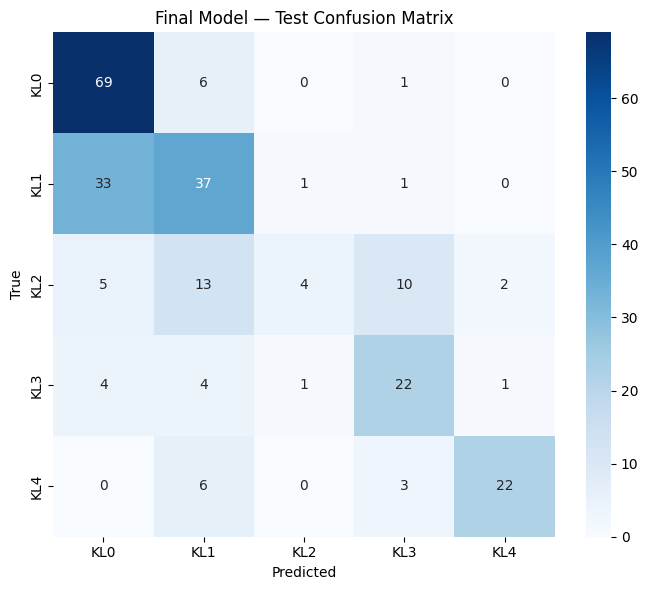

In [ ]:
final_model = tf.keras.models.load_model("/content/best_finetuned.keras")

test_loss, test_acc = final_model.evaluate(test_ds, verbose=1)
print(f"\nFINAL TEST ACCURACY: {test_acc:.4f}  ({test_acc*100:.2f}%)")

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = final_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true, y_pred = np.array(y_true), np.array(y_pred)
class_labels = ["KL0", "KL1", "KL2", "KL3", "KL4"]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=3, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Final Model — Test Confusion Matrix")
plt.tight_layout(); plt.show()


---
## Optional — ordinal head instead of plain softmax

KL grades are ordered (0 < 1 < 2 < 3 < 4), but plain softmax + cross-entropy treats every wrong class as equally wrong — a KL0→KL4 mistake and a KL0→KL1 mistake get the same penalty. With a dataset this small, that's wasted signal. This is the "extended binary classification" ordinal trick (Frank & Hall): instead of one 5-way softmax, predict 4 independent binary questions — *"is the grade greater than k?"* for k = 0,1,2,3 — and sum the yes-votes to get the final grade.

Try this only if Stages 1–2 above are working and you have time left; it's a head swap, not a rewrite. Reuse the same `backbone` / data pipeline, just change the last layers and the label encoding.

In [ ]:
def to_ordinal_labels(grades, num_classes=5):
    # grades: array of ints 0..4  ->  shape (N, num_classes-1) binary targets
    grades = np.asarray(grades)
    thresholds = np.arange(num_classes - 1)
    return (grades[:, None] > thresholds[None, :]).astype("float32")

# Example of building an ordinal dataset from train_df/val_df/test_df:
def make_ordinal_dataset(split_df, training):
    labels_ord = to_ordinal_labels(split_df["grade"].values)
    ds = tf.data.Dataset.from_tensor_slices((split_df["filepath"].values, labels_ord))
    ds = ds.map(lambda fp, lab: (load_image(fp, 0)[0], lab), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(len(split_df), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Ordinal head: same backbone, 4 sigmoid outputs instead of 5-way softmax
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
ord_base = tf.keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
ord_base.trainable = False
x = ord_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
ordinal_outputs = tf.keras.layers.Dense(4, activation="sigmoid")(x)   # 4 = num_classes - 1
ordinal_model = tf.keras.Model(inputs, ordinal_outputs)

ordinal_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# To predict a grade from an ordinal model's output:
def ordinal_to_grade(sigmoid_outputs, threshold=0.5):
    return (sigmoid_outputs > threshold).sum(axis=1)

print("Ordinal model built. Train it the same way as Stage 1/2 above,")
print("using make_ordinal_dataset(...) in place of make_dataset(...),")
print("and ordinal_to_grade(...) when computing predictions for the classification report.")


Ordinal model built. Train it the same way as Stage 1/2 above,
using make_ordinal_dataset(...) in place of make_dataset(...),
and ordinal_to_grade(...) when computing predictions for the classification report.


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true_grade = []
y_prob_5class = []

for images, labels in test_ds:
    probs = final_model.predict(images, verbose=0)
    y_true_grade.extend(labels.numpy())
    y_prob_5class.extend(probs)

y_true_grade = np.array(y_true_grade)
y_prob_5class = np.array(y_prob_5class)

y_true_binary = (y_true_grade >= 2).astype(int)
p_oa_present = y_prob_5class[:, 2:].sum(axis=1)   # P(KL2) + P(KL3) + P(KL4)
y_pred_binary = (p_oa_present > 0.5).astype(int)

print(classification_report(y_true_binary, y_pred_binary,
      target_names=["No/Doubtful", "Definite OA"], digits=3))
cm = confusion_matrix(y_true_binary, y_pred_binary)
tn, fp, fn, tp = cm.ravel()
print("Sensitivity:", tp/(tp+fn), " Specificity:", tn/(tn+fp))

              precision    recall  f1-score   support

 No/Doubtful      0.850     0.959     0.902       148
 Definite OA      0.923     0.742     0.823        97

    accuracy                          0.873       245
   macro avg      0.887     0.851     0.862       245
weighted avg      0.879     0.873     0.870       245

Sensitivity: 0.7422680412371134  Specificity: 0.9594594594594594
